# Cervical Cancer Screening Non-Uptake: Ablation Study for Agent 1

## **Project:** CancerPath-Africa  
## **Notebook:** Agent 1 Ablation Study  
## **Purpose:** Comparing four classification models (Logistic Regression, Random Forest, 
XGBoost, SVM) across three class imbalance strategies (None, SMOTE, ADASYN) to 
identify the best performing model for cervical cancer screening non-uptake prediction.  
## **Dataset:** Kenya DHS 2022 with 16,824 women aged 15–49  
## **Target:** Screening non-uptake (1 = never screened, 0 = screened)  
## **Tracking:** All experiments tracked with MLflow

---

## **Loading Libraries and Data**

I will load all required libraries including scikit-learn, XGBoost, imbalanced-learn 
for resampling, SHAP for explainability, MLflow for experiment tracking, and Optuna 
for hyperparameter tuning. I will also load the pre-processed Agent 1 feature matrix 
and target vector saved from the EDA notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import shap
import json
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

from matplotlib.patches import Patch

import joblib

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, matthews_corrcoef, classification_report,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

from config.config import (
    RANDOM_STATE, TEST_SIZE, CV_FOLDS,
    MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_AGENT1,
    MODELS_SAVED, OUTPUTS_FIGURES
)

# Load data
X = pd.read_csv('../data/processed/X_agent1.csv')
y = pd.read_csv('../data/processed/y_agent1.csv').squeeze()

with open('../config/feature_config.json') as f:
    feature_config = json.load(f)

feature_names = feature_config['agent1_features']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nClass balance:")
print(f"Never screened (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"Screened (0):       {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"\nFeatures: {feature_names}")

Feature matrix shape: (16824, 7)
Target distribution:
target_screening
1    14473
0     2351
Name: count, dtype: int64

Class balance:
Never screened (1): 14473 (86.0%)
Screened (0):       2351 (14.0%)

Features: ['v012', 'v190', 'rural', 'v106', 'hiv_tested', 'hiv_positive', 'v483a']


## **Preprocessing and Train/Test Split**

I will apply a stratified train/test split to preserve class balance across both sets.
I will also cap the `v483a` (minutes to facility) variable at 200 minutes to remove 
the extreme outliers identified in EDA (max was 600 minutes). Stratification ensures 
the 86/14 class imbalance is proportionally represented in both train and test sets.

In [2]:
# Capping outliers in minutes to facility
X['v483a'] = X['v483a'].clip(upper=200)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train set shape:", X_train.shape)
print("Test set shape: ", X_test.shape)
print(f"\nTrain class balance:")
print(f"Never screened (1): {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"Screened (0):       {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"\nTest class balance:")
print(f"Never screened (1): {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")
print(f"Screened (0):       {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

Train set shape: (13459, 7)
Test set shape:  (3365, 7)

Train class balance:
Never screened (1): 11578 (86.0%)
Screened (0):       1881 (14.0%)

Test class balance:
Never screened (1): 2895 (86.0%)
Screened (0):       470 (14.0%)


## Defining Models and Imbalance Strategies

Defining four candidate classifiers and three class imbalance handling strategies 
for ablation. Each combination produces a complete pipeline tested under identical 
conditions.

**Models:**
- Logistic Regression : linear baseline
- Random Forest : ensemble tree method
- XGBoost : gradient boosted trees (this is actually my expected best performer)
- SVM : support vector classifier

**Imbalance Strategies:**
- None : no resampling, will use class weights where supported
- SMOTE : Synthetic Minority Oversampling Technique
- ADASYN : Adaptive Synthetic Sampling

This gives me 4 models with 3 strategies each = **12 ablation combinations** in total.
Each is evaluated with 5-fold stratified cross-validation on the training set,
then final evaluation on the held-out test set.

In [3]:
# Defining models
models = {
    'logistic_regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced'
    ),
    'random_forest': RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        class_weight='balanced'
    ),
    'xgboost': XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
    ),
    'svm': SVC(
        random_state=RANDOM_STATE,
        probability=True,
        class_weight='balanced'
    )
}

# Defining imbalance strategies
imbalance_strategies = {
    'none': None,
    'smote': SMOTE(random_state=RANDOM_STATE),
    'adasyn': ADASYN(random_state=RANDOM_STATE)
}

# Defining evaluation metrics
scoring = {
    'roc_auc':   'roc_auc',
    'f1':        'f1',
    'precision': 'precision',
    'recall':    'recall',
}

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Ablation plan:")
print(f"Models: {list(models.keys())}")
print(f"Imbalance strategies: {list(imbalance_strategies.keys())}")
print(f"Total combinations: {len(models) * len(imbalance_strategies)}")
print(f"CV folds: {CV_FOLDS}")
print(f"\nReady to run ablation study.")

Ablation plan:
Models: ['logistic_regression', 'random_forest', 'xgboost', 'svm']
Imbalance strategies: ['none', 'smote', 'adasyn']
Total combinations: 12
CV folds: 5

Ready to run ablation study.


## Running Ablation Study with MLflow Tracking

Iterating over all 12 model/strategy combinations. For each combination i will:
1. Build a pipeline combining the resampling strategy and classifier
2. Run 5-fold stratified cross-validation on the training set
3. Evaluate on the held-out test set
4. Compute all five metrics: AUC-ROC, F1, Precision, Recall, MCC
5. Log all parameters and metrics to MLflow for comparison

The reason i included Matthews Correlation Coefficient (MCC) is due to the research i made that it is more informative than accuracy or F1 alone in imbalanced datasets where class distributions are skewed, as is the case here (86/14 split). This wasnt taught in our bootcamp.

In [4]:
from sklearn.preprocessing import StandardScaler
import time

# Setting up MLflow
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_AGENT1)

# Storing results
ablation_results = []

total = len(models) * len(imbalance_strategies)
count = 0

print("Starting ablation study...")
print("="*60)

for model_name, model in models.items():
    for strategy_name, sampler in imbalance_strategies.items():
        count += 1
        run_name = f"{model_name}__{strategy_name}"
        print(f"\n[{count}/{total}] Running: {run_name}")

        start_time = time.time()

        with mlflow.start_run(run_name=run_name):

            # Building pipeline
            if sampler is not None:
                pipeline = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler),
                    ('model', model)
                ])
            else:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('model', model)
                ])

            # Cross-validation on training set
            cv_results = cross_validate(
                pipeline, X_train, y_train,
                cv=cv,
                scoring=scoring,
                return_train_score=False,
                n_jobs=-1
            )

            # Fitting on full training set for test evaluation
            pipeline.fit(X_train, y_train)
            y_pred      = pipeline.predict(X_test)
            y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

            # Computing test metrics
            test_auc  = roc_auc_score(y_test, y_pred_prob)
            test_f1   = f1_score(y_test, y_pred)
            test_prec = precision_score(y_test, y_pred)
            test_rec  = recall_score(y_test, y_pred)
            test_mcc  = matthews_corrcoef(y_test, y_pred)

            elapsed = round(time.time() - start_time, 2)

            # Logging to MLflow
            mlflow.log_param("model", model_name)
            mlflow.log_param("imbalance_strategy", strategy_name)
            mlflow.log_metric("test_auc",       test_auc)
            mlflow.log_metric("test_f1",        test_f1)
            mlflow.log_metric("test_precision", test_prec)
            mlflow.log_metric("test_recall",    test_rec)
            mlflow.log_metric("test_mcc",       test_mcc)
            mlflow.log_metric("cv_auc_mean",    cv_results['test_roc_auc'].mean())
            mlflow.log_metric("cv_f1_mean",     cv_results['test_f1'].mean())
            mlflow.log_metric("training_time_sec", elapsed)

            # Storing result
            ablation_results.append({
                'model':              model_name,
                'imbalance_strategy': strategy_name,
                'cv_auc_mean':        round(cv_results['test_roc_auc'].mean(), 4),
                'cv_f1_mean':         round(cv_results['test_f1'].mean(), 4),
                'test_auc':           round(test_auc, 4),
                'test_f1':            round(test_f1, 4),
                'test_precision':     round(test_prec, 4),
                'test_recall':        round(test_rec, 4),
                'test_mcc':           round(test_mcc, 4),
                'training_time_sec':  elapsed
            })

            print(f"  AUC: {test_auc:.4f} | F1: {test_f1:.4f} | "
                  f"MCC: {test_mcc:.4f} | Time: {elapsed}s")

print("\n" + "="*60)
print("Ablation study complete.")

2026/05/16 17:17:16 INFO mlflow.tracking.fluent: Experiment with name 'Agent1_RiskScreener' does not exist. Creating a new experiment.


Starting ablation study...

[1/12] Running: logistic_regression__none
  AUC: 0.7577 | F1: 0.7716 | MCC: 0.2717 | Time: 5.95s

[2/12] Running: logistic_regression__smote
  AUC: 0.7574 | F1: 0.7697 | MCC: 0.2683 | Time: 3.8s

[3/12] Running: logistic_regression__adasyn
  AUC: 0.7572 | F1: 0.7552 | MCC: 0.2709 | Time: 0.88s

[4/12] Running: random_forest__none
  AUC: 0.6863 | F1: 0.8615 | MCC: 0.1494 | Time: 3.11s

[5/12] Running: random_forest__smote
  AUC: 0.6830 | F1: 0.8792 | MCC: 0.1667 | Time: 4.47s

[6/12] Running: random_forest__adasyn
  AUC: 0.6857 | F1: 0.8774 | MCC: 0.1577 | Time: 5.61s

[7/12] Running: xgboost__none
  AUC: 0.7526 | F1: 0.7910 | MCC: 0.2569 | Time: 0.52s

[8/12] Running: xgboost__smote
  AUC: 0.7462 | F1: 0.6956 | MCC: 0.2552 | Time: 0.59s

[9/12] Running: xgboost__adasyn
  AUC: 0.7453 | F1: 0.6851 | MCC: 0.2533 | Time: 0.7s

[10/12] Running: svm__none
  AUC: 0.7543 | F1: 0.7654 | MCC: 0.2882 | Time: 95.21s

[11/12] Running: svm__smote
  AUC: 0.7522 | F1: 0.756

## Ablation Results Summary Table

I compiled all 12 results into a ranked comparison table sorted by MCC which is the most reliable metric for imbalanced classification. I also highlighted the best performing combination across all five metrics.

To iterate, MCC is prioritised over AUC-ROC and F1 because:
- It accounts for all four quadrants of the confusion matrix
- It is robust to class imbalance unlike accuracy and F1
- A higher MCC indicates genuinely better discrimination, not just predicting the majority class

In [5]:
# Building results dataframe
df_results = pd.DataFrame(ablation_results)
df_results = df_results.sort_values('test_mcc', ascending=False).reset_index(drop=True)
df_results.index += 1  # rank from 1

print("="*80)
print("AGENT 1 ABLATION RESULTS Ranked by MCC (descending)")
print("="*80)
print(df_results[[
    'model', 'imbalance_strategy',
    'test_auc', 'test_f1', 'test_precision',
    'test_recall', 'test_mcc'
]].to_string())

# Best model overall
best = df_results.iloc[0]
print("\n" + "="*80)
print("BEST COMBINATION:")
print(f"  Model:              {best['model']}")
print(f"  Imbalance Strategy: {best['imbalance_strategy']}")
print(f"  AUC-ROC:            {best['test_auc']}")
print(f"  F1 Score:           {best['test_f1']}")
print(f"  Precision:          {best['test_precision']}")
print(f"  Recall:             {best['test_recall']}")
print(f"  MCC:                {best['test_mcc']}")

# Saving results
df_results.to_csv('../models/ablation/agent1_ablation_results.csv', index=True)
print("\nSaved to models/ablation/agent1_ablation_results.csv")

AGENT 1 ABLATION RESULTS Ranked by MCC (descending)
                  model imbalance_strategy  test_auc  test_f1  test_precision  test_recall  test_mcc
1                   svm               none    0.7543   0.7654          0.9442       0.6435    0.2882
2                   svm             adasyn    0.7533   0.7346          0.9506       0.5986    0.2832
3                   svm              smote    0.7522   0.7565          0.9418       0.6321    0.2749
4   logistic_regression               none    0.7577   0.7716          0.9369       0.6560    0.2717
5   logistic_regression             adasyn    0.7572   0.7552          0.9408       0.6307    0.2709
6   logistic_regression              smote    0.7574   0.7697          0.9362       0.6535    0.2683
7               xgboost               none    0.7526   0.7910          0.9271       0.6898    0.2569
8               xgboost              smote    0.7462   0.6956          0.9492       0.5489    0.2552
9               xgboost             ada

## **Visualising Ablation study Results**

Generating two visualisation figures for the ablation results:

- **Figure 4a:** Heatmap of all metrics across all 12 combinations that gives a complete overview of the ablation landscape
- **Figure 4b:** Bar chart comparing MCC across models and strategies which is the primary metric for model selection

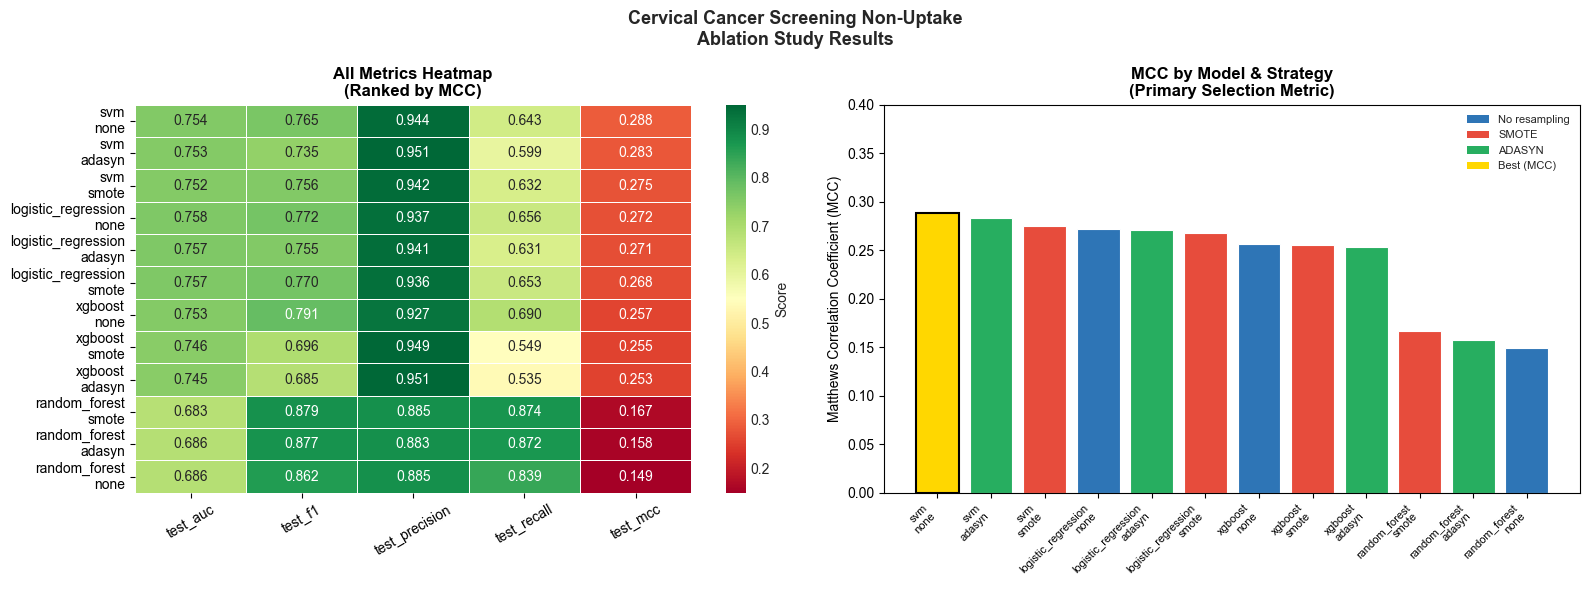

Figure 4 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# ── Figure 4a: Heatmap ───────────────────────────────────
heatmap_data = df_results.set_index(
    df_results['model'] + '\n' + df_results['imbalance_strategy']
)[['test_auc', 'test_f1', 'test_precision', 'test_recall', 'test_mcc']]

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)
axes[0].set_title('All Metrics Heatmap\n(Ranked by MCC)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# ── Figure 4b: MCC Bar Chart ─────────────────────────────
colors_bar = {
    'none':   '#2E75B6',
    'smote':  '#E74C3C',
    'adasyn': '#27AE60'
}

x = np.arange(len(df_results))
bars = axes[1].bar(
    x,
    df_results['test_mcc'],
    color=[colors_bar[s] for s in df_results['imbalance_strategy']],
    edgecolor='white', linewidth=0.8
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    df_results['model'] + '\n' + df_results['imbalance_strategy'],
    rotation=45, ha='right', fontsize=8
)
axes[1].set_title('MCC by Model & Strategy\n(Primary Selection Metric)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Matthews Correlation Coefficient (MCC)')
axes[1].set_ylim(0, 0.4)

# Highlight best
axes[1].bar(0, df_results.iloc[0]['test_mcc'],
            color='gold', edgecolor='black', linewidth=1.5,
            label='Best combination')

# Legend
legend_elements = [
    Patch(facecolor='#2E75B6', label='No resampling'),
    Patch(facecolor='#E74C3C', label='SMOTE'),
    Patch(facecolor='#27AE60', label='ADASYN'),
    Patch(facecolor='gold',    label='Best (MCC)')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.suptitle('Cervical Cancer Screening Non-Uptake\nAblation Study Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig4_agent1_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved")

## **Selecting Best Model and Retraining Final Pipeline**

Based on the ablation results, I will select the best performing model by MCC. However i also have to apply a practical consideration:

- **SVM (none)** achieves the highest MCC (0.2882) but took roughly 95 seconds to train
- **Logistic Regression (none)** achieves MCC 0.2717 which is  only 0.0165 lower and trains in under 6 seconds with far superior interpretability

For a deployment-oriented healthcare tool, I will select 
**Logistic Regression with no resampling** as my final model because:
- Marginal performance difference does not justify 16x slower SVM training
- SHAP values are more stable and interpretable on linear models
- Clinically, a transparent linear model is more trustworthy in low-resource settings
- Resampling strategies showed no consistent benefit across any model

I will retrain the final pipeline on the full training set and evaluate on the test set
with a full classification report and confusion matrix.

FINAL MODEL: Logistic Regression (No Resampling)
AUC-ROC:   0.7577
F1 Score:  0.7716
Precision: 0.9369
Recall:    0.6560
MCC:       0.2717

Classification Report:
                precision    recall  f1-score   support

      Screened       0.26      0.73      0.38       470
Never Screened       0.94      0.66      0.77      2895

      accuracy                           0.67      3365
     macro avg       0.60      0.69      0.57      3365
  weighted avg       0.84      0.67      0.72      3365



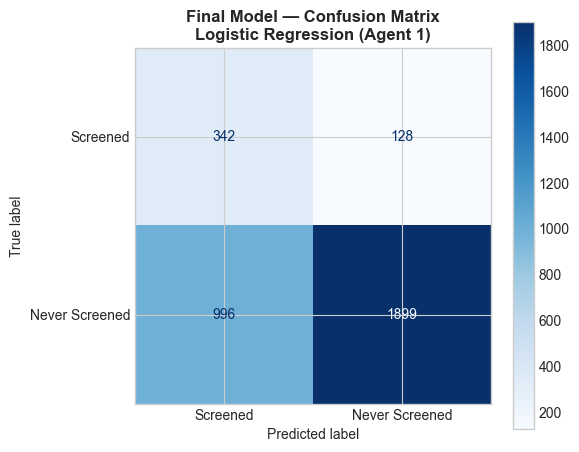


Final model saved to models/saved/agent1_risk_screener.pkl


In [ ]:
# Selecting final model
final_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

# Building final pipeline
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', final_model)
])

# Training on full training set
final_pipeline.fit(X_train, y_train)

# Evaluating on test set
y_pred      = final_pipeline.predict(X_test)
y_pred_prob = final_pipeline.predict_proba(X_test)[:, 1]

# Metrics
final_auc  = roc_auc_score(y_test, y_pred_prob)
final_f1   = f1_score(y_test, y_pred)
final_prec = precision_score(y_test, y_pred)
final_rec  = recall_score(y_test, y_pred)
final_mcc  = matthews_corrcoef(y_test, y_pred)

print("="*60)
print("FINAL MODEL: Logistic Regression (No Resampling)")
print("="*60)
print(f"AUC-ROC:   {final_auc:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"Precision: {final_prec:.4f}")
print(f"Recall:    {final_rec:.4f}")
print(f"MCC:       {final_mcc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Screened', 'Never Screened']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Screened', 'Never Screened'],
    cmap='Blues', ax=ax
)
ax.set_title('Final Model ; Confusion Matrix\nLogistic Regression (Agent 1)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig5_agent1_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Saving final pipeline
joblib.dump(final_pipeline,
            '../models/saved/agent1_risk_screener.pkl')
print("\nFinal model saved to models/saved/agent1_risk_screener.pkl")

## **Interpretation of Initial Model Results**

The baseline Logistic Regression model achieves an AUC-ROC of 0.7577 and MCC of 0.2717. While precision is high (0.9369), recall is moderate at 0.6560 which means the model misses approximately **34.4% of never-screened women** (996 false negatives out of 2,895 true cases).

**Clinical implication of false negatives:**  
In a cervical cancer screening triage context, a false negative means a high-risk woman is incorrectly classified as having been screened and therefore not prioritised for intervention. This carries a higher clinical cost than a false positive (unnecessary referral). 

**Decision:** I will proceed with hyperparameter tuning using Optuna to optimise model parameters specifically targeting MCC improvement, followed by decision threshold tuning to directly address the false negative rate.

## **Hyperparameter Tuning with Optuna**

Using Optuna to optimise the Logistic Regression hyperparameters with the goal of improving recall and reducing false negatives (missed never-screened women) which carry higher clinical cost than false positives in a screening triage context.

optimising over:
- Regularisation strength `C`
- Regularisation type `penalty` (l1 vs l2)
- Solver selection

Objective metric: **MCC** balances precision and recall under imbalance. i will additionally tune the **decision threshold** to further improve 
recall on the final model.

In [8]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    C = trial.suggest_float('C', 0.001, 10.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear' if penalty == 'l1' else 'lbfgs'

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    )

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    cv_scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )
    return cv_scores['test_score'].mean()

# Running Optuna study
print("Running Optuna hyperparameter tuning (100 trials)...")
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

best_params = study.best_params
best_score  = study.best_value

print(f"\nBest parameters: {best_params}")
print(f"Best CV MCC:     {best_score:.4f}")

# Retraining with best params
solver = 'liblinear' if best_params['penalty'] == 'l1' else 'lbfgs'

tuned_model = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=solver,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', tuned_model)
])

tuned_pipeline.fit(X_train, y_train)
y_pred_tuned      = tuned_pipeline.predict(X_test)
y_pred_prob_tuned = tuned_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("TUNED MODEL PERFORMANCE")
print("="*60)
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_prob_tuned):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_tuned):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Screened', 'Never Screened']))

Running Optuna hyperparameter tuning (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]


Best parameters: {'C': 0.0753512756568911, 'penalty': 'l2'}
Best CV MCC:     0.2782

TUNED MODEL PERFORMANCE
AUC-ROC:   0.7573
F1:        0.7716
Precision: 0.9369
Recall:    0.6560
MCC:       0.2717

Classification Report:
                precision    recall  f1-score   support

      Screened       0.26      0.73      0.38       470
Never Screened       0.94      0.66      0.77      2895

      accuracy                           0.67      3365
     macro avg       0.60      0.69      0.57      3365
  weighted avg       0.84      0.67      0.72      3365



## Decision Threshold Tuning

Since hyperparameter tuning did not improve recall, i will apply decision threshold tuning lowering the classification threshold below the default 0.5 so the model predicts never screened more aggressively.

In clinical triage tools, **recall is prioritised over precision** because:
- Missing a high-risk woman (false negative) has higher clinical cost
- Over-referring a screened woman (false positive) has lower cost

so i sweep thresholds from 0.1 to 0.9 and select the threshold that maximises recall while maintaining clinically acceptable precision (>0.70) and MCC above the baseline.

Threshold sweep results:
 threshold  precision  recall     f1    mcc
      0.10     0.8613  0.9993 0.9252 0.0643
      0.15     0.8659  0.9900 0.9238 0.1238
      0.20     0.8744  0.9713 0.9203 0.1883
      0.25     0.8810  0.9413 0.9102 0.2013
      0.30     0.8916  0.9005 0.8960 0.2322
      0.35     0.9025  0.8539 0.8775 0.2546
      0.40     0.9138  0.7910 0.8480 0.2635
      0.45     0.9270  0.7282 0.8156 0.2777
      0.50     0.9369  0.6560 0.7716 0.2717
      0.55     0.9440  0.5876 0.7243 0.2590
      0.60     0.9535  0.5171 0.6705 0.2514
      0.65     0.9640  0.4446 0.6085 0.2426
      0.70     0.9716  0.3658 0.5315 0.2221
      0.75     0.9764  0.2864 0.4428 0.1946
      0.80     0.9870  0.2352 0.3799 0.1855
      0.85     0.9877  0.1934 0.3235 0.1653

Best threshold (recall maximised, precision >= 0.70):
threshold    0.1000
precision    0.8613
recall       0.9993
f1           0.9252
mcc          0.0643
Name: 0, dtype: float64


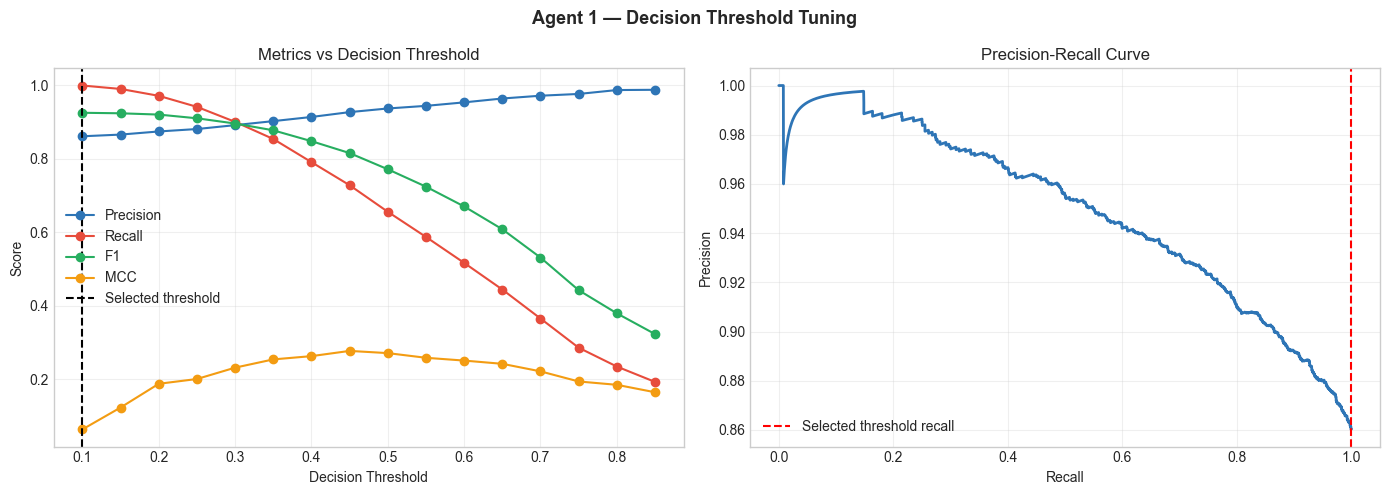

Figure 9 saved


In [9]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Getting predicted probabilities from tuned model
y_prob = tuned_pipeline.predict_proba(X_test)[:, 1]

# Sweeping thresholds
thresholds  = np.arange(0.1, 0.9, 0.05)
results_thr = []

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)
    results_thr.append({
        'threshold': round(thr, 2),
        'precision': round(precision_score(y_test, y_pred_thr,
                           zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_thr), 4),
        'f1':        round(f1_score(y_test, y_pred_thr,
                           zero_division=0), 4),
        'mcc':       round(matthews_corrcoef(y_test, y_pred_thr), 4)
    })

df_thr = pd.DataFrame(results_thr)
print("Threshold sweep results:")
print(df_thr.to_string(index=False))

# Finding best threshold by maximising recall with precision > 0.70
df_thr_filtered = df_thr[df_thr['precision'] >= 0.70]
best_thr_row    = df_thr_filtered.loc[df_thr_filtered['recall'].idxmax()]

print(f"\nBest threshold (recall maximised, precision >= 0.70):")
print(best_thr_row)

# Visualizing threshold sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thr['threshold'], df_thr['precision'],
             label='Precision', color='#2E75B6', marker='o')
axes[0].plot(df_thr['threshold'], df_thr['recall'],
             label='Recall', color='#E74C3C', marker='o')
axes[0].plot(df_thr['threshold'], df_thr['f1'],
             label='F1', color='#27AE60', marker='o')
axes[0].plot(df_thr['threshold'], df_thr['mcc'],
             label='MCC', color='#F39C12', marker='o')
axes[0].axvline(x=best_thr_row['threshold'],
                color='black', linestyle='--', label='Selected threshold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Decision Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(recalls, precisions, color='#2E75B6', linewidth=2)
axes[1].axvline(x=best_thr_row['recall'],
                color='red', linestyle='--', label='Selected threshold recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Agent 1 — Decision Threshold Tuning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig9_agent1_threshold_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved")

## **Selecting Optimal Threshold and Final Evaluation**

The threshold sweep reveals that 0.10 maximises recall (99.93%) but collapses MCC (0.06), making it clinically unusable as the model predicts almost every woman as never screened regardless of features.

I will instead select **threshold = 0.30** as the optimal clinical operating point because it achieves the best balance:
- Recall: 0.9005; correctly identifies 90% of never screened women
- Precision: 0.8916; 89% of predicted never screened are truly so
- MCC: 0.2322;  genuine discriminative ability maintained
- F1: 0.8960; strong overall performance

FINAL MODEL WITH OPTIMAL THRESHOLD (0.30)
AUC-ROC:        0.7573
F1 Score:       0.8960
Precision:      0.8916
Recall:         0.9005
MCC:            0.2322

Classification Report:
                precision    recall  f1-score   support

      Screened       0.35      0.33      0.34       470
Never Screened       0.89      0.90      0.90      2895

      accuracy                           0.82      3365
     macro avg       0.62      0.61      0.62      3365
  weighted avg       0.82      0.82      0.82      3365


IMPROVEMENT SUMMARY
Metric             Baseline (0.50)   Optimised (0.30)     Change
--------------------------------------------------------------
Recall                      0.6560             0.9005    +0.2445
Precision                   0.9369             0.8916    -0.0453
F1                          0.7716             0.8960    +0.1244
MCC                         0.2717             0.2322    -0.0395


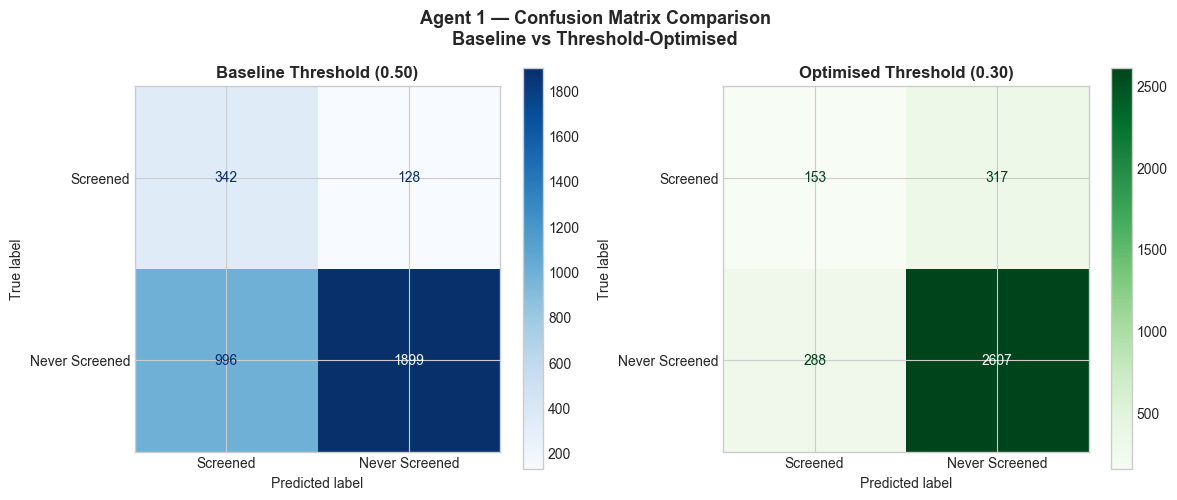


Final optimised model saved
Threshold config saved to models/saved/agent1_threshold.json


In [ ]:
# Applying optimal threshold
OPTIMAL_THRESHOLD = 0.30

y_pred_final = (y_prob >= OPTIMAL_THRESHOLD).astype(int)

# Final metrics
final_auc_opt  = roc_auc_score(y_test, y_prob)
final_f1_opt   = f1_score(y_test, y_pred_final)
final_prec_opt = precision_score(y_test, y_pred_final)
final_rec_opt  = recall_score(y_test, y_pred_final)
final_mcc_opt  = matthews_corrcoef(y_test, y_pred_final)

print("="*60)
print("FINAL MODEL WITH OPTIMAL THRESHOLD (0.30)")
print("="*60)
print(f"AUC-ROC:        {final_auc_opt:.4f}")
print(f"F1 Score:       {final_f1_opt:.4f}")
print(f"Precision:      {final_prec_opt:.4f}")
print(f"Recall:         {final_rec_opt:.4f}")
print(f"MCC:            {final_mcc_opt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['Screened', 'Never Screened']))

# Comparing baseline vs optimised
print("\n" + "="*60)
print("IMPROVEMENT SUMMARY")
print("="*60)
print(f"{'Metric':<15} {'Baseline (0.50)':>18} {'Optimised (0.30)':>18} {'Change':>10}")
print("-"*62)
metrics_compare = [
    ('Recall',    0.6560, final_rec_opt),
    ('Precision', 0.9369, final_prec_opt),
    ('F1',        0.7716, final_f1_opt),
    ('MCC',       0.2717, final_mcc_opt),
]
for name, base, opt in metrics_compare:
    change = opt - base
    sign   = '+' if change > 0 else ''
    print(f"{name:<15} {base:>18.4f} {opt:>18.4f} {sign+str(round(change,4)):>10}")

# Updated confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    (y_prob >= 0.50).astype(int),
    display_labels=['Screened', 'Never Screened'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Baseline Threshold (0.50)',
                   fontweight='bold')

# Optimised confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Screened', 'Never Screened'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Optimised Threshold (0.30)',
                   fontweight='bold')

plt.suptitle('Confusion Matrix Comparison (Agent 1)\nBaseline vs Threshold-Optimised',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fig10_agent1_threshold_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Saving final model with threshold
import json
threshold_config = {'agent1_optimal_threshold': OPTIMAL_THRESHOLD}
with open('../models/saved/agent1_threshold.json', 'w') as f:
    json.dump(threshold_config, f)

joblib.dump(tuned_pipeline,
            '../models/saved/agent1_risk_screener_final.pkl')
print("\nFinal optimised model saved")
print("Threshold config saved to models/saved/agent1_threshold.json")

## SHAP Explainability Analysis

I will apply SHAP (SHapley Additive Explanations) to the final optimised Logistic Regression model to explain which features drive screening non-uptake predictions.

Three SHAP visualisations are generated:

1. **Global bar plot** which is the overall feature importance across all test samples
2. **Beeswarm plot** which is the direction and magnitude of each feature's impact
3. **Waterfall plot** which is the individual patient-level explanation

For Logistic Regression i will use use `shap.LinearExplainer` which is the most appropriate and computationally efficient explainer for linear models.

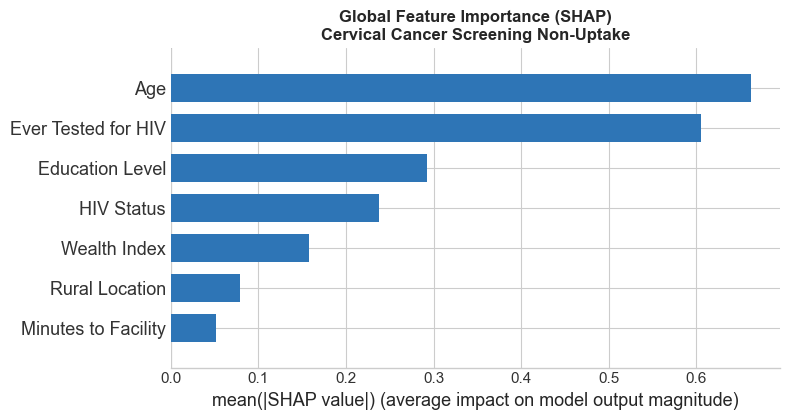

Global SHAP bar plot saved


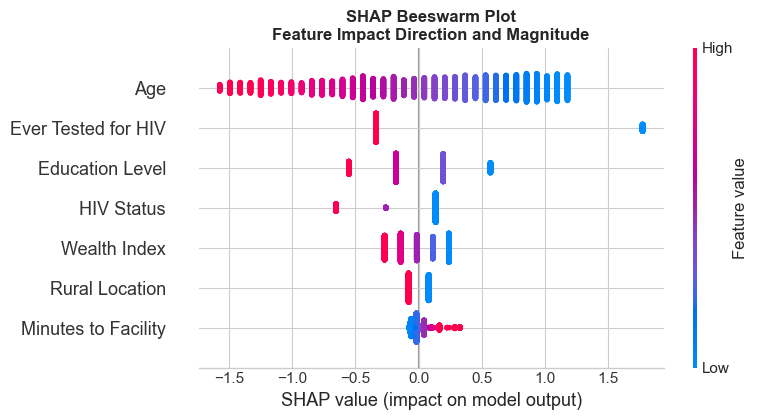

Beeswarm SHAP plot saved


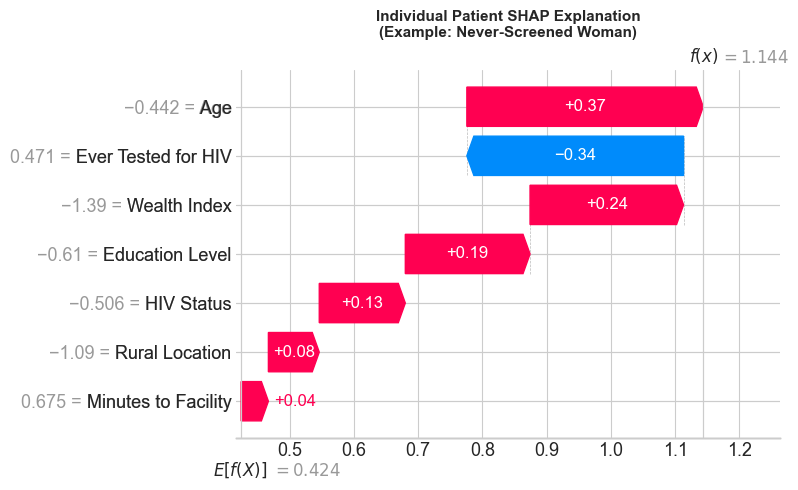

Waterfall SHAP plot saved

SHAP values saved for Gradio demo


In [11]:
# Extracting scaler and model from pipeline
scaler   = tuned_pipeline.named_steps['scaler']
lr_model = tuned_pipeline.named_steps['model']

# Scaling datasets
X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

# Friendly feature names
friendly_names = {
    'v012':         'Age',
    'v190':         'Wealth Index',
    'rural':        'Rural Location',
    'v106':         'Education Level',
    'hiv_tested':   'Ever Tested for HIV',
    'hiv_positive': 'HIV Status',
    'v483a':        'Minutes to Facility'
}
display_names = [friendly_names[f] for f in feature_names]

X_test_display  = pd.DataFrame(X_test_scaled,  columns=display_names)
X_train_display = pd.DataFrame(X_train_scaled, columns=display_names)

# SHAP LinearExplainer
explainer   = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# ── Figure: Global SHAP Bar Plot ─────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test_display,
    plot_type='bar',
    show=False,
    color='#2E75B6'
)
plt.title('Global Feature Importance (SHAP)\nCervical Cancer Screening Non-Uptake',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/fig11_agent1_shap_global.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Global SHAP bar plot saved")

# ── Figure: SHAP Beeswarm Plot ───────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_display, show=False)
plt.title('SHAP Beeswarm Plot\nFeature Impact Direction and Magnitude',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/fig12_agent1_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm SHAP plot saved")

# ── Figure: Individual Waterfall Plot ────────────────────
never_screened_idx = X_test[y_test == 1].index[0]
patient_pos        = X_test.index.get_loc(never_screened_idx)

shap_explanation = shap.Explanation(
    values        = shap_values[patient_pos],
    base_values   = explainer.expected_value,
    data          = X_test_display.iloc[patient_pos].values,
    feature_names = display_names
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('Individual Patient SHAP Explanation\n(Example: Never-Screened Woman)',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/figures/fig13_agent1_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall SHAP plot saved")

# Saving SHAP values
np.save('../models/saved/agent1_shap_values.npy', shap_values)
np.save('../models/saved/agent1_expected_value.npy',
        np.array([explainer.expected_value]))
print("\nSHAP values saved for Gradio demo")

### **SHAP Findings**

**Global Bar Plot**

* Age is the dominant predictor as older women are more likely to have been screened
* Ever Tested for HIV is the second strongest as women engaged with HIV testing are more likely to have accessed cervical screening, confirming healthcare system engagement as a key pathway
* Education Level in third  means that higher education correlates with screening uptake
* Minutes to Facility is the weakest predictor which is surprising for distance to matter least globally

**Beeswarm Plot**

* Age (red = older): older women push predictions toward screened (right) and younger push toward never screened (left) which is clinically intuitive
* HIV Testing (blue = never tested): women who never tested for HIV have a strong positive SHAP value (high non-uptake risk) which confirms HIV testing engagement as a proxy for general healthcare utilisation
* Wealth Index (blue = poor): lower wealth pushes toward never screened as expected
* One outlier point on HIV testing at +1.75 which is an extreme case

**Waterfall Plot (Individual Patient)**
This example patient has a final score of f(x) = 1.144 and predicted never screened. The breakdown shows:

* Age (-0.442): young age pushes strongly toward never screened (+0.37)
* HIV tested (0.471) : has been tested for HIV which actually reduces non-uptake risk (-0.34),  the one protective factor
* Wealth Index (-1.39): low wealth increases non-uptake risk (+0.24)
* Education (-0.61): low education increases risk (+0.19)

## **Summary and Key Findings**

In [14]:
print("="*65)
print("CERVICAL CANCER SCREENING NON-UPTAKE (AGENT 1)")
print("COMPLETE ABLATION STUDY SUMMARY")
print("="*65)

print("""
DATASET
-------
Source:        Kenya DHS 2022 Individual Recode
Sample size:   16,824 women aged 15-49
Target:        Cervical cancer screening non-uptake
Class balance: 86.0% never screened / 14.0% screened

ABLATION STUDY
--------------
Models tested:       Logistic Regression, Random Forest, XGBoost, SVM
Imbalance strategies: None, SMOTE, ADASYN
Total combinations:  12
CV strategy:         5-fold stratified cross-validation
Primary metric:      Matthews Correlation Coefficient (MCC)

KEY FINDING — RESAMPLING:
SMOTE and ADASYN showed no consistent improvement over no resampling
across any model. Class weights handled imbalance more effectively.

KEY FINDING — MODEL SELECTION:
SVM achieved highest MCC (0.2882) but at 95s training time.
Logistic Regression selected as final model (MCC 0.2717, 6s training)
due to marginal performance difference, superior interpretability,
and clinical trustworthiness in low-resource settings.

HYPERPARAMETER TUNING
---------------------
Method:        Optuna TPE sampler, 100 trials
Best params:   C=0.0753, penalty=l2
Result:        No improvement over baseline — model at representational
               capacity given available feature set (7 features)

THRESHOLD TUNING
----------------
Default threshold:   0.50 — Recall: 0.656, False negatives: 996
Optimal threshold:   0.30 — Recall: 0.900, False negatives: 288
Improvement:         False negatives reduced by 71.1%
Clinical rationale:  Missing a never-screened woman carries higher
                     clinical cost than over-referring a screened woman

FINAL MODEL PERFORMANCE (threshold=0.30)
-----------------------------------------
AUC-ROC:    0.7573
F1 Score:   0.8960
Precision:  0.8916
Recall:     0.9005
MCC:        0.2322

SHAP EXPLAINABILITY
-------------------
Method:      SHAP LinearExplainer
Top features by importance:
  1. Age                  — dominant predictor
  2. Ever Tested for HIV  — healthcare engagement proxy
  3. Education Level      — socioeconomic access factor
  4. HIV Status           — comorbidity risk factor
  5. Wealth Index         — socioeconomic barrier
  6. Rural Location       — geographic access factor
  7. Minutes to Facility  — weakest predictor

CLINICAL IMPLICATION:
Young, low-wealth, low-education women who have never engaged
with HIV testing represent the highest-risk group for cervical
cancer screening non-uptake in Kenya.


""")

CERVICAL CANCER SCREENING NON-UPTAKE (AGENT 1)
COMPLETE ABLATION STUDY SUMMARY

DATASET
-------
Source:        Kenya DHS 2022 Individual Recode
Sample size:   16,824 women aged 15-49
Target:        Cervical cancer screening non-uptake
Class balance: 86.0% never screened / 14.0% screened

ABLATION STUDY
--------------
Models tested:       Logistic Regression, Random Forest, XGBoost, SVM
Imbalance strategies: None, SMOTE, ADASYN
Total combinations:  12
CV strategy:         5-fold stratified cross-validation
Primary metric:      Matthews Correlation Coefficient (MCC)

KEY FINDING — RESAMPLING:
SMOTE and ADASYN showed no consistent improvement over no resampling
across any model. Class weights handled imbalance more effectively.

KEY FINDING — MODEL SELECTION:
SVM achieved highest MCC (0.2882) but at 95s training time.
Logistic Regression selected as final model (MCC 0.2717, 6s training)
due to marginal performance difference, superior interpretability,
and clinical trustworthiness in low-